# HMM Simulator — Basic Usage

This notebook walks through the core functionality of the `hmm_simulator` package:

1. Simulate a single screening history
2. Simulate a population of profiles
3. Sparsify profiles to mimic real-world irregular screening
4. Visualise results

**States**

| Value | Label | Meaning |
|-------|-------|---------|
| 0 | — | Censored / missing |
| 1 | N0 | Normal |
| 2 | L1 | Low-grade lesion |
| 3 | H2 | High-grade lesion |
| 4 | C3 | Carcinoma |

> **Tip:** Run cells top-to-bottom with `Shift+Enter`.

## Setup

Install the package from the repo root if you haven't already:

```bash
pip install -e ..
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from hmm_simulator.hmm_generator import simulate_profile
from hmm_simulator.sparsify import sample_screenings
from hmm_simulator.plotting import plot_profile, plot_hmap, plot_histogram
from hmm_simulator.utils import NUM_TIMEPOINTS

np.random.seed(42)

---
## 1. Simulate a Single Profile

A **profile** is a 1-D array of length `NUM_TIMEPOINTS` (321).
Each index represents one timepoint; the value is the clinical state at that time.

- `init_age` — timepoint index at which screening begins
- `age_max` — timepoint index at which screening ends

In [2]:
init_age = 0
age_max  = 60

profile = simulate_profile(NUM_TIMEPOINTS, init_age, age_max)

print(f"Array length : {len(profile)}")
print(f"Unique states: {sorted(set(profile.astype(int)))}")
print(f"First 20 values:\n{profile[:20]}")

Array length : 321
Unique states: [np.int64(1)]
First 20 values:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


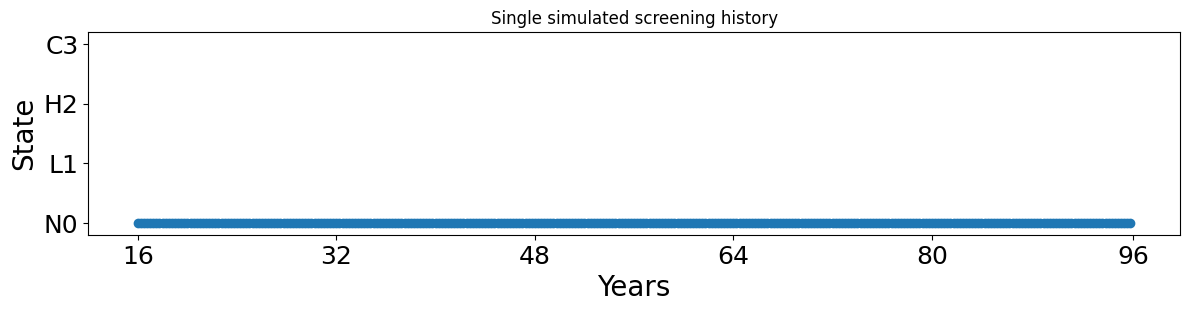

In [3]:
fig, ax = plt.subplots(figsize=(12, 3))
plot_profile(profile, ax, show=False)
ax.set_title("Single simulated screening history")
plt.show()

---
## 2. Simulate a Population

Generate many profiles by sampling random entry (`init_age`) and exit (`age_max`) timepoints from uniform distributions.

In [4]:
N_SAMPLES = 500

# Uniform entry probability across all timepoints.
proba_init = np.ones(NUM_TIMEPOINTS) / NUM_TIMEPOINTS

profiles = []
for _ in tqdm(range(N_SAMPLES), desc="Simulating"):
    i_age = int(np.random.choice(NUM_TIMEPOINTS, p=proba_init))
    # Exit is drawn uniformly from the remaining timepoints.
    remaining = NUM_TIMEPOINTS - i_age
    a_max = i_age + int(np.random.choice(remaining))
    if a_max <= i_age:
        a_max = i_age + 1
    a_max = min(a_max, 60)  # cap to stay within safe age-group bounds
    i_age = min(i_age, a_max - 1)
    profiles.append(simulate_profile(NUM_TIMEPOINTS, i_age, a_max))

X = np.array(profiles)
print(f"Population shape: {X.shape}")

Simulating: 100%|██████████| 500/500 [00:00<00:00, 8661.48it/s]

Population shape: (500, 321)


### Heatmap — population at a glance

Each row is one individual; each column is a timepoint.
White cells are censored/missing.

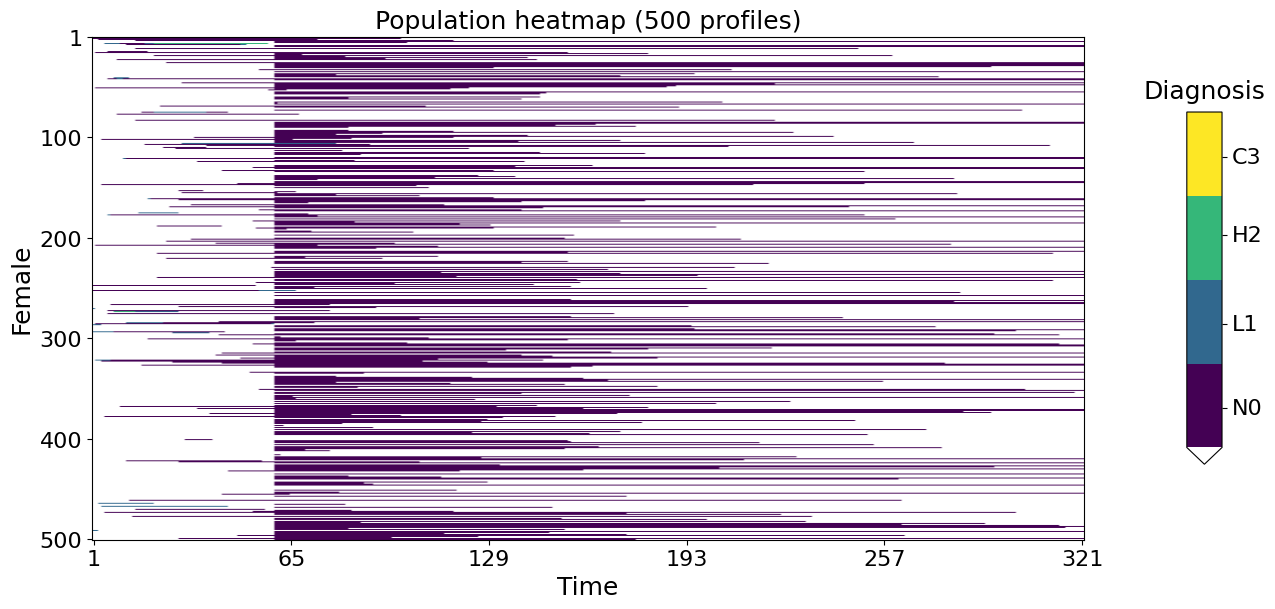

In [5]:
fig = plt.figure(figsize=(14, 6))
plot_hmap(fig, X, show=False)
plt.title(f"Population heatmap ({N_SAMPLES} profiles)", fontsize=18)
plt.show()

### State distribution

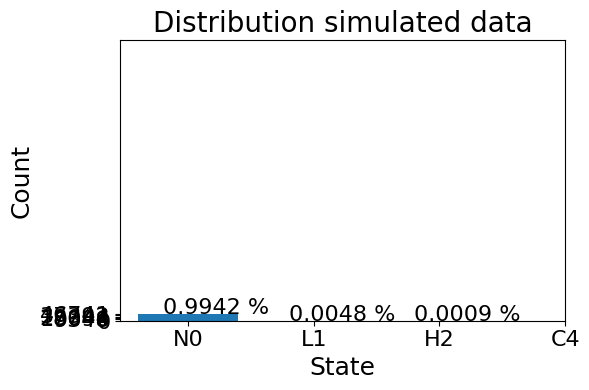

In [6]:
plt.figure(figsize=(6, 4))
plot_histogram(X, show=False)
plt.show()

---
## 3. Sparsify — Mimic Real-World Screening

Real screening programmes don't observe every timepoint.
`sample_screenings` keeps only every `stepsize`-th observed timepoint,
simulating irregular screening intervals.

In [7]:
STEPSIZE = 5  # keep every 5th timepoint

X_sparse = sample_screenings(X, stepsize=STEPSIZE)

dense_obs  = int((X  != 0).sum())
sparse_obs = int((X_sparse != 0).sum())

print(f"Dense  profiles : {X.shape[0]}  |  non-zero observations: {dense_obs}")
print(f"Sparse profiles : {X_sparse.shape[0]}  |  non-zero observations: {sparse_obs}")
print(f"Reduction       : {100 * (1 - sparse_obs / dense_obs):.1f}%")

Dense  profiles : 500  |  non-zero observations: 47013
Sparse profiles : 358  |  non-zero observations: 9462
Reduction       : 79.9%


### Compare a single dense vs. sparse profile

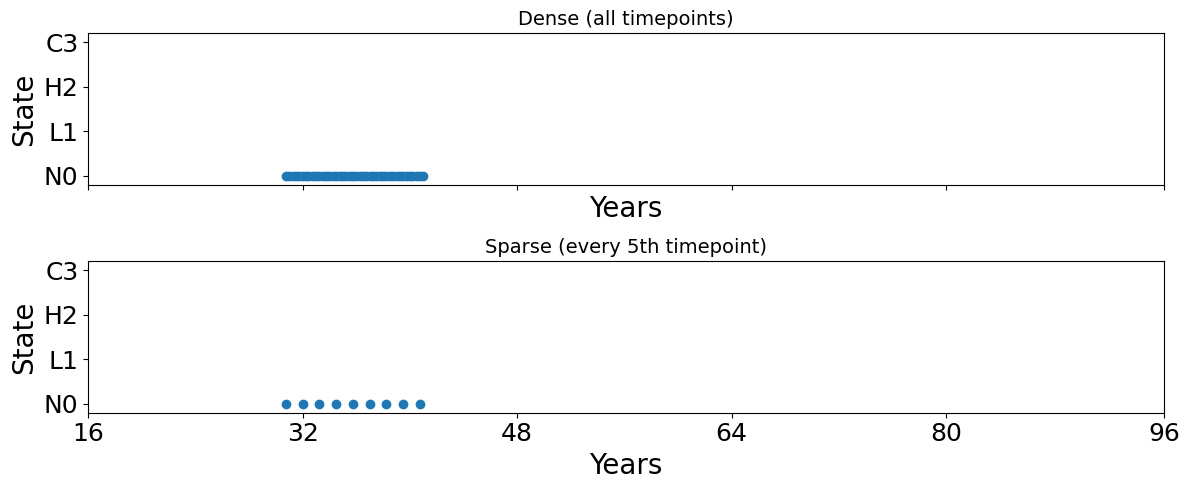

In [8]:
idx = 0  # pick the first profile that survived sparsification

# Find the same profile in the original dense array.
# X_sparse rows may be a subset of X rows, so we match by content.
dense_row  = X[idx]
sparse_row = X_sparse[idx]

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
plot_profile(dense_row,  axes[0], show=False)
plot_profile(sparse_row, axes[1], show=False)
axes[0].set_title("Dense (all timepoints)",     fontsize=14)
axes[1].set_title(f"Sparse (every {STEPSIZE}th timepoint)", fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Grid of Profiles

A quick way to visually inspect variability across individuals.

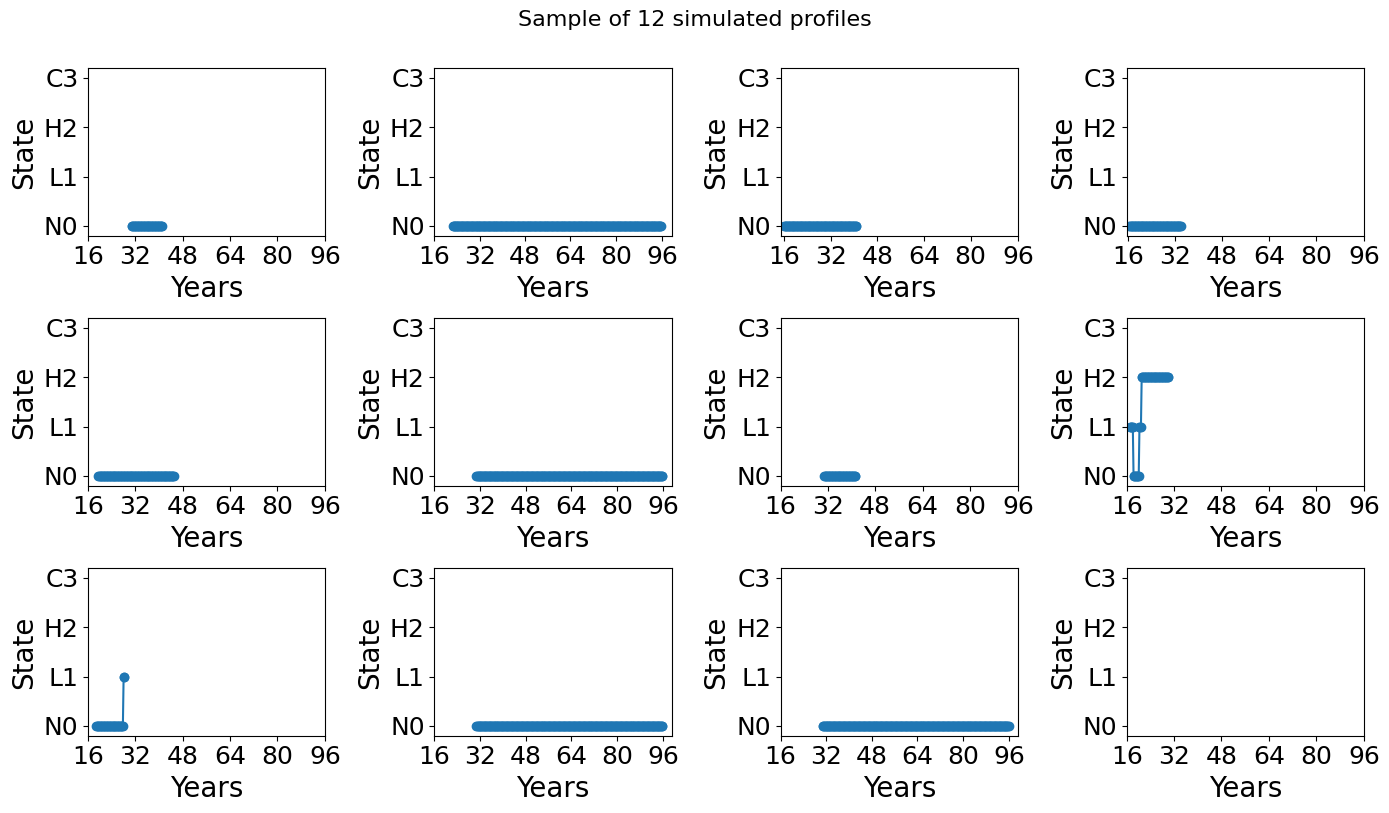

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for ax, profile in zip(axes.ravel(), X[:12]):
    plot_profile(profile, ax, show=False)
plt.suptitle("Sample of 12 simulated profiles", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()